In [57]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv(
    "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"
)

print("="*50)
print("DATASET SHAPE")
print(df.shape)
print("="*50)

df.head()

DATASET SHAPE
(8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [58]:
# =====================================================
# BASIC INFO
# =====================================================

print(df.info())

print("\n")

print(df.describe())

print("\n")

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8173 entries, 0 to 8172
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8173 non-null   str    
 1   event_type             8173 non-null   str    
 2   latitude               8173 non-null   float64
 3   longitude              8173 non-null   float64
 4   endlatitude            8004 non-null   float64
 5   endlongitude           8004 non-null   float64
 6   address                8170 non-null   str    
 7   end_address            687 non-null    str    
 8   event_cause            8173 non-null   str    
 9   requires_road_closure  8173 non-null   bool   
 10  start_datetime         8173 non-null   str    
 11  end_datetime           490 non-null    str    
 12  status                 8173 non-null   str    
 13  authenticated          8173 non-null   str    
 14  modified_datetime      8173 non-null   str    
 15  map_file       

In [59]:
# =====================================================
# OVERVIEW
# =====================================================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names\n")

for col in df.columns:
    print(col)

Rows : 8173
Columns : 46

Column Names

id
event_type
latitude
longitude
endlatitude
endlongitude
address
end_address
event_cause
requires_road_closure
start_datetime
end_datetime
status
authenticated
modified_datetime
map_file
direction
description
veh_type
veh_no
corridor
priority
cargo_material
reason_breakdown
age_of_truck
created_date
route_path
client_id
created_by_id
last_modified_by_id
assigned_to_police_id
citizen_accident_id
comment
police_station
meta_data
kgid
resolved_at_address
resolved_at_latitude
resolved_at_longitude
closed_by_id
closed_datetime
resolved_by_id
resolved_datetime
gba_identifier
zone
junction


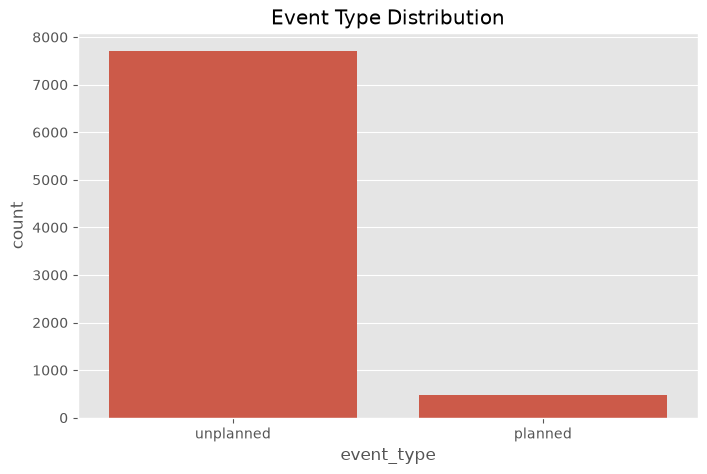

In [60]:
# =====================================================
# EVENT TYPE
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="event_type",
    data=df
)

plt.title(
    "Event Type Distribution"
)

plt.show()

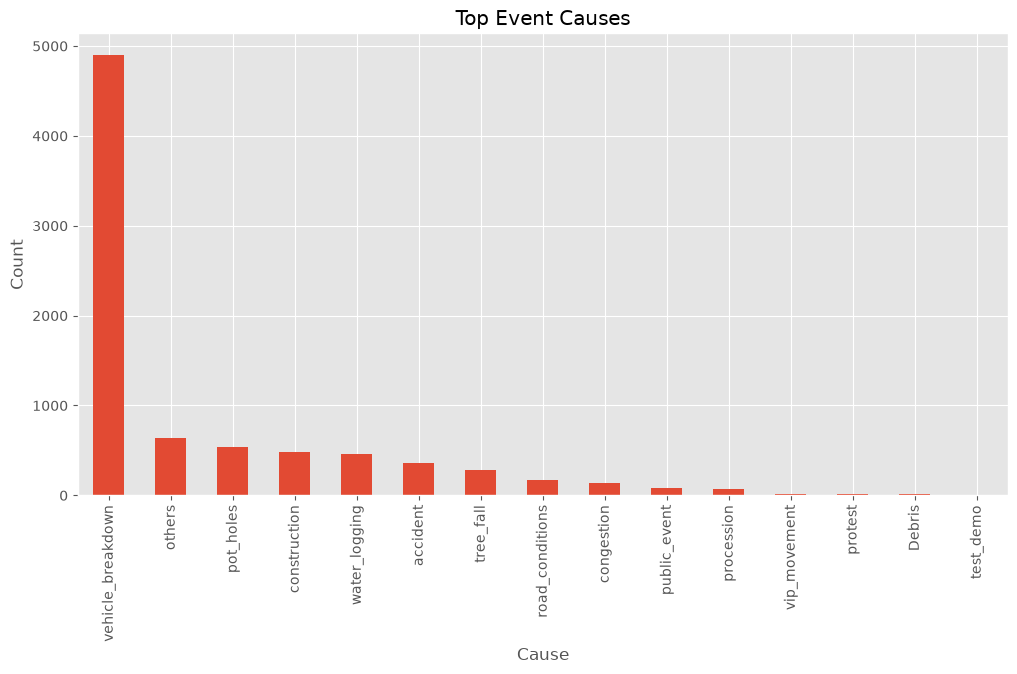

In [61]:
# =====================================================
# TOP EVENT CAUSES
# =====================================================

plt.figure(figsize=(12,6))

df["event_cause"] \
.value_counts() \
.head(15) \
.plot(kind="bar")

plt.title(
    "Top Event Causes"
)

plt.xlabel("Cause")

plt.ylabel("Count")

plt.show()

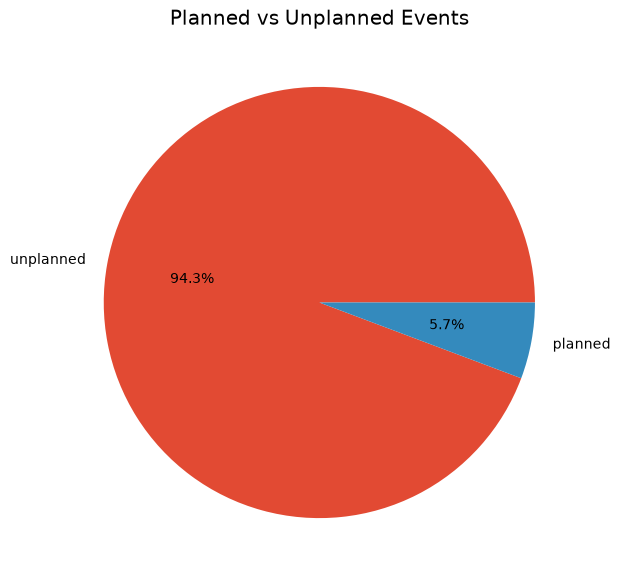

In [62]:
# =====================================================
# PIE CHART
# =====================================================

event_counts = (
    df["event_type"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    event_counts,
    labels=event_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Planned vs Unplanned Events"
)

plt.show()

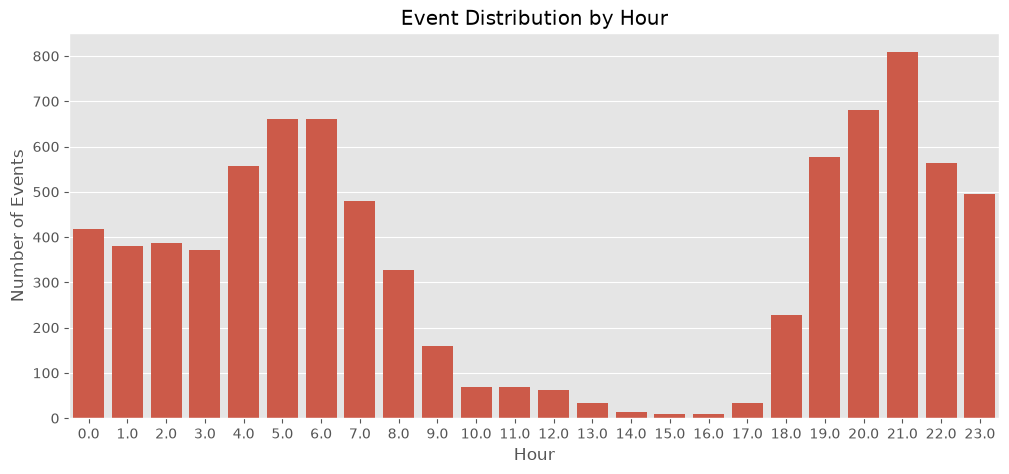

In [63]:
if "hour" not in df.columns:
    df["start_datetime"] = pd.to_datetime(df["start_datetime"], errors="coerce")
    df["hour"] = df["start_datetime"].dt.hour

plt.figure(figsize=(12,5))

sns.countplot(
    x="hour",
    data=df
)

plt.title("Event Distribution by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Events")

plt.show()

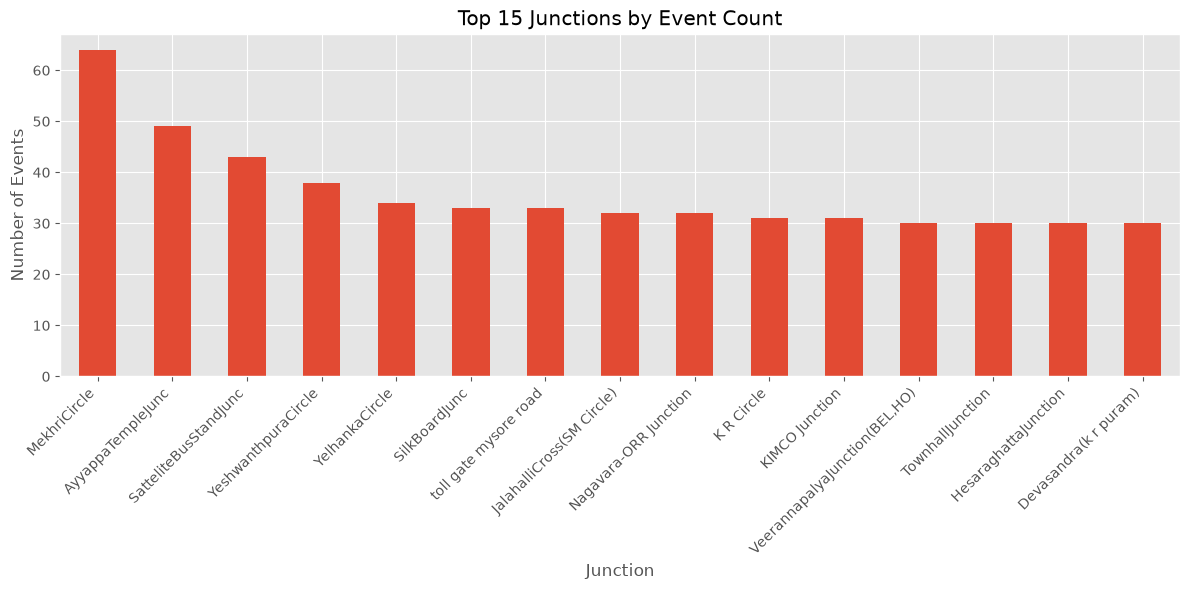

In [64]:
# =====================================================
# JUNCTION ANALYSIS
# =====================================================

plt.figure(figsize=(12, 6))

df['junction'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Junctions by Event Count')

plt.xlabel('Junction')

plt.ylabel('Number of Events')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

In [65]:
df.columns

Index(['id', 'event_type', 'latitude', 'longitude', 'endlatitude',
       'endlongitude', 'address', 'end_address', 'event_cause',
       'requires_road_closure', 'start_datetime', 'end_datetime', 'status',
       'authenticated', 'modified_datetime', 'map_file', 'direction',
       'description', 'veh_type', 'veh_no', 'corridor', 'priority',
       'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date',
       'route_path', 'client_id', 'created_by_id', 'last_modified_by_id',
       'assigned_to_police_id', 'citizen_accident_id', 'comment',
       'police_station', 'meta_data', 'kgid', 'resolved_at_address',
       'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id',
       'closed_datetime', 'resolved_by_id', 'resolved_datetime',
       'gba_identifier', 'zone', 'junction', 'hour'],
      dtype='str')

In [66]:
# Convert to datetime
df['start_datetime'] = pd.to_datetime(df['start_datetime'])

# Create day_of_week column
df['day_of_week'] = df['start_datetime'].dt.day_name()

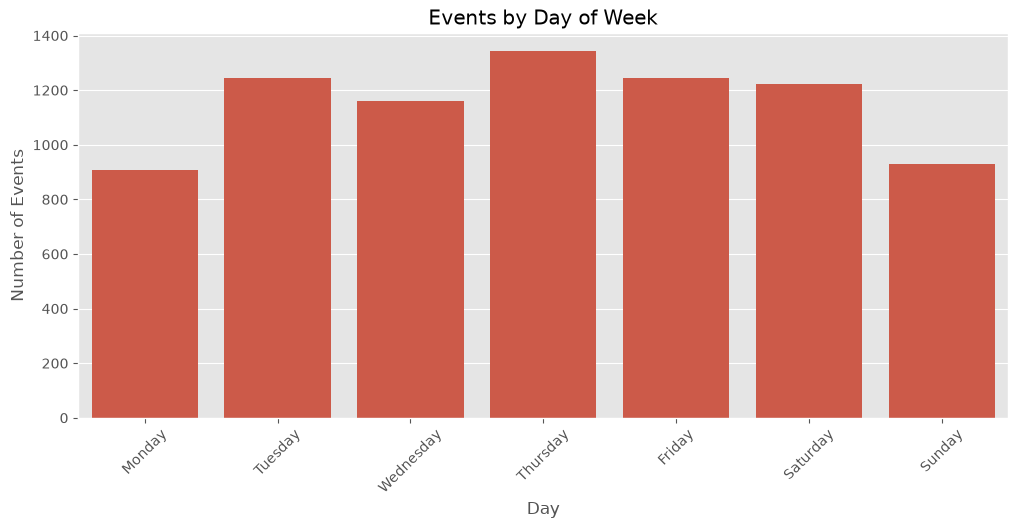

In [67]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='day_of_week',
    data=df,
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title('Events by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

In [68]:
import pandas as pd
import numpy as np

# Convert datetime columns
datetime_cols = [
    'start_datetime',
    'end_datetime',
    'modified_datetime',
    'resolved_datetime'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create useful time features
df['year'] = df['start_datetime'].dt.year
df['month'] = df['start_datetime'].dt.month
df['month_name'] = df['start_datetime'].dt.month_name()
df['day'] = df['start_datetime'].dt.day
df['day_of_week'] = df['start_datetime'].dt.day_name()
df['weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Resolution Time
df['resolution_hours'] = (
    df['resolved_datetime'] - df['start_datetime']
).dt.total_seconds() / 3600

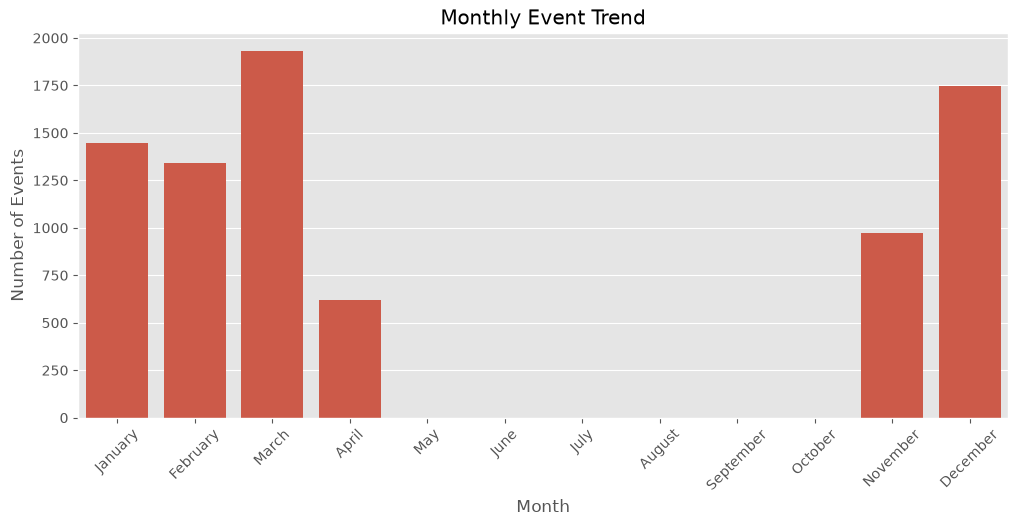

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_events = (
    df.groupby('month_name')
      .size()
      .reindex([
          'January','February','March','April',
          'May','June','July','August',
          'September','October','November','December'
      ])
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_events.index,
    y=monthly_events.values
)

plt.title("Monthly Event Trend")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)

plt.show()

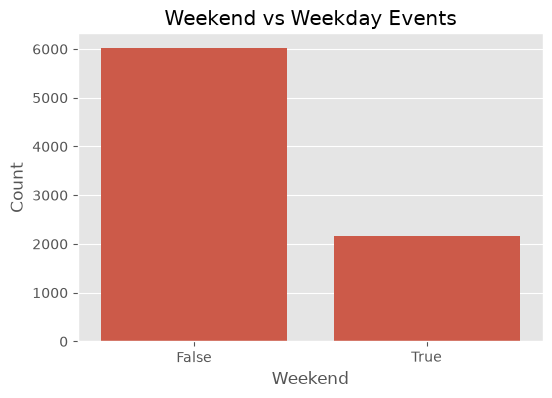

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='weekend',
    data=df
)

plt.title("Weekend vs Weekday Events")
plt.xlabel("Weekend")
plt.ylabel("Count")

plt.show()

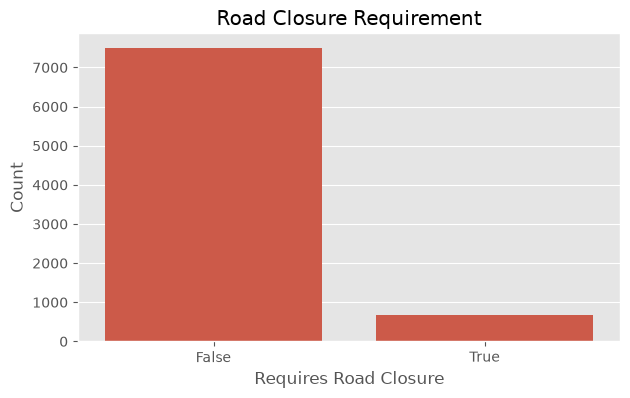

In [71]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='requires_road_closure',
    data=df
)

plt.title("Road Closure Requirement")
plt.xlabel("Requires Road Closure")
plt.ylabel("Count")

plt.show()

<Figure size 1400x600 with 0 Axes>

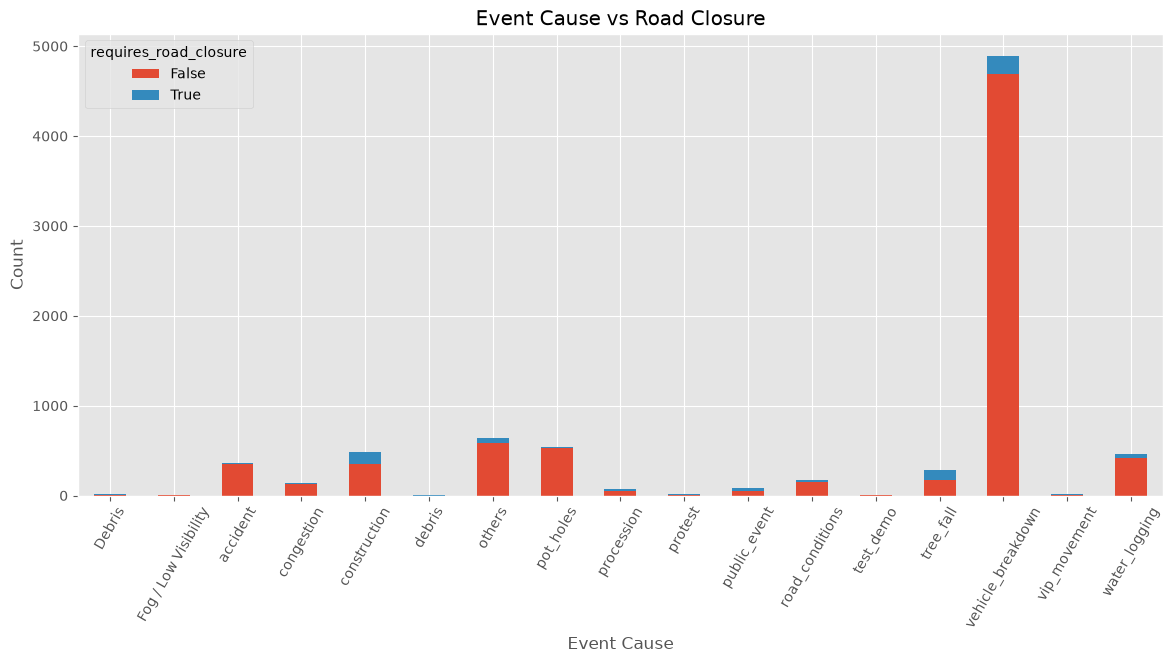

In [72]:
plt.figure(figsize=(14,6))

cross = pd.crosstab(
    df['event_cause'],
    df['requires_road_closure']
)

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title("Event Cause vs Road Closure")
plt.xlabel("Event Cause")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

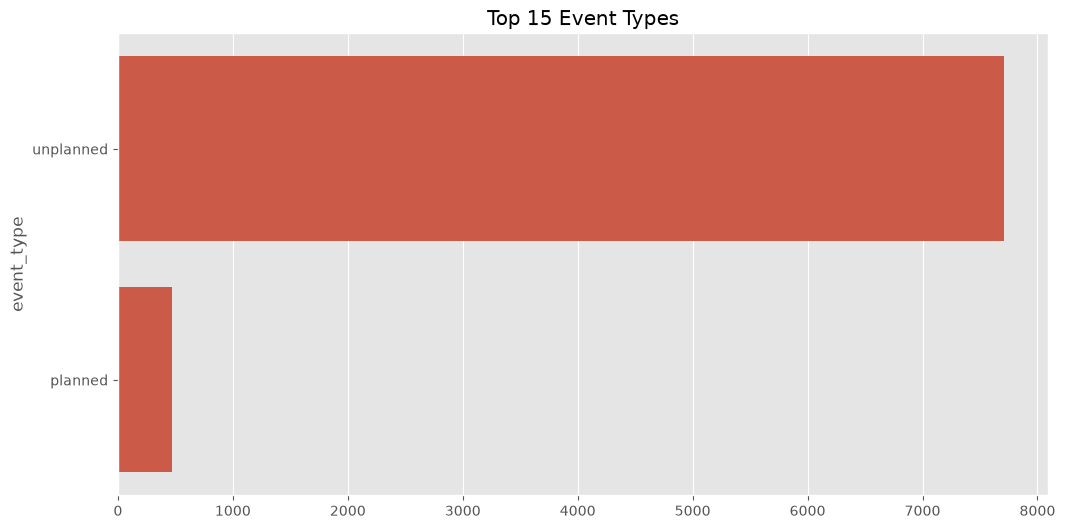

In [73]:
top_events = df['event_type'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_events.values,
    y=top_events.index
)

plt.title("Top 15 Event Types")

plt.show()

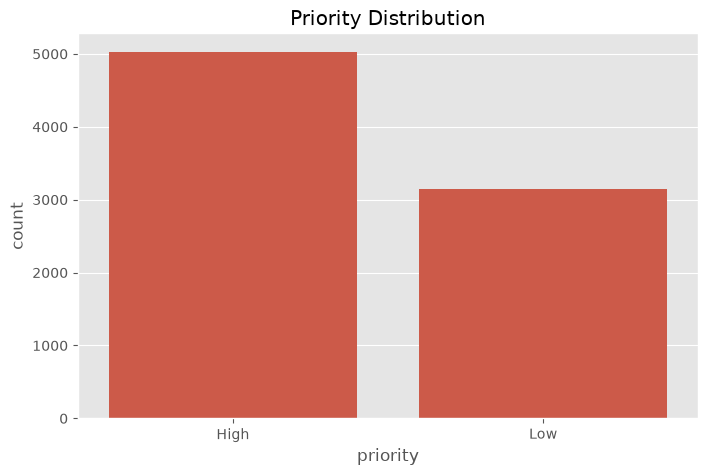

In [74]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='priority',
    data=df
)

plt.title("Priority Distribution")

plt.show()

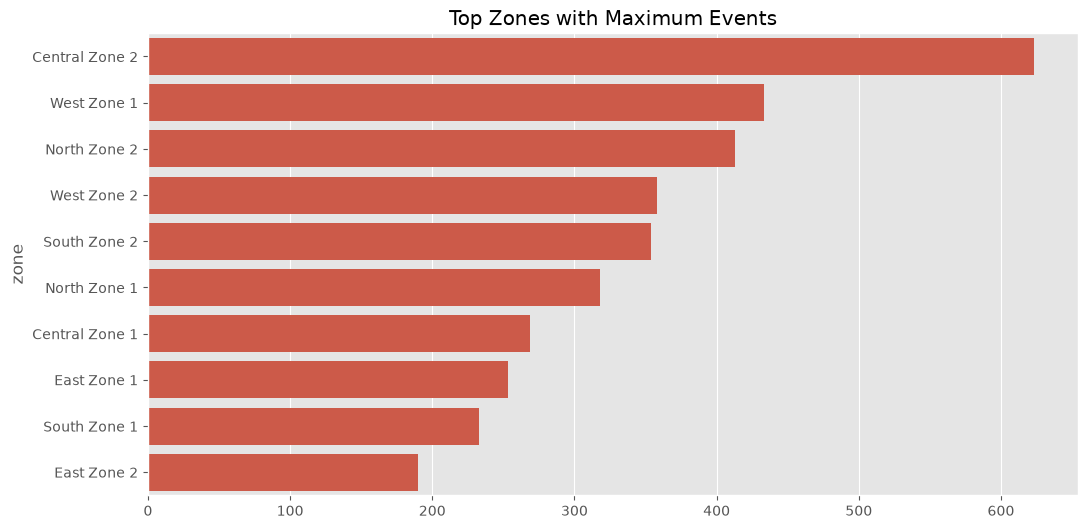

In [75]:
top_zones = df['zone'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_zones.values,
    y=top_zones.index
)

plt.title("Top Zones with Maximum Events")

plt.show()

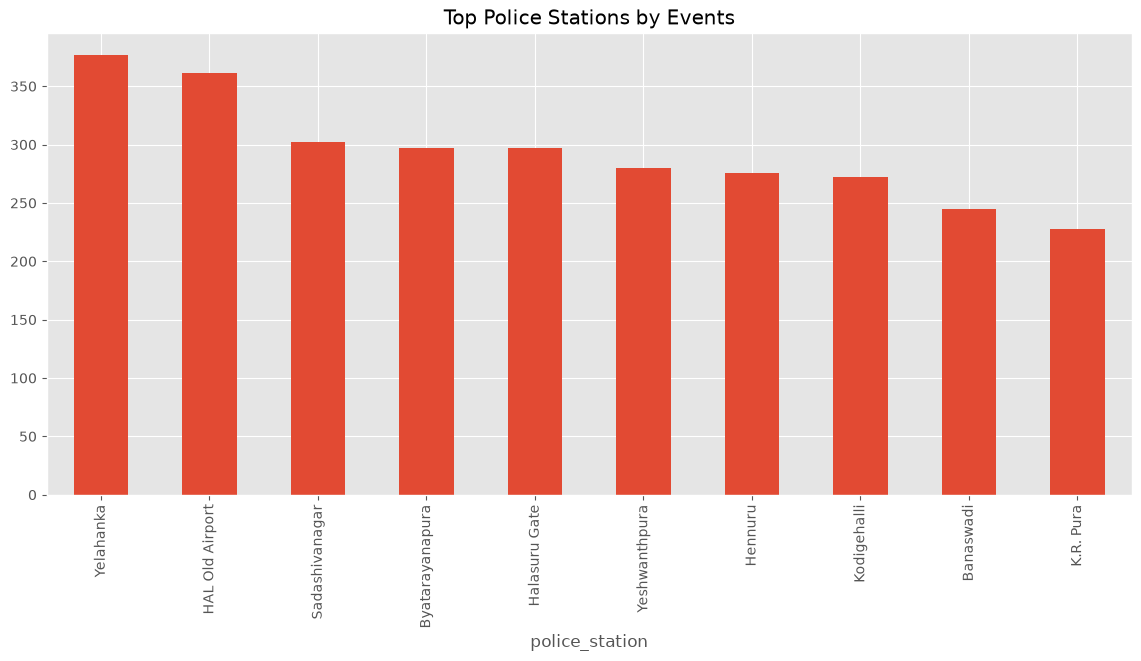

In [76]:
# =====================================================
# POLICE STATION
# =====================================================

plt.figure(figsize=(14,6))

df["police_station"] \
.value_counts() \
.head(10) \
.plot(kind="bar")

plt.title(
    "Top Police Stations by Events"
)

plt.show()

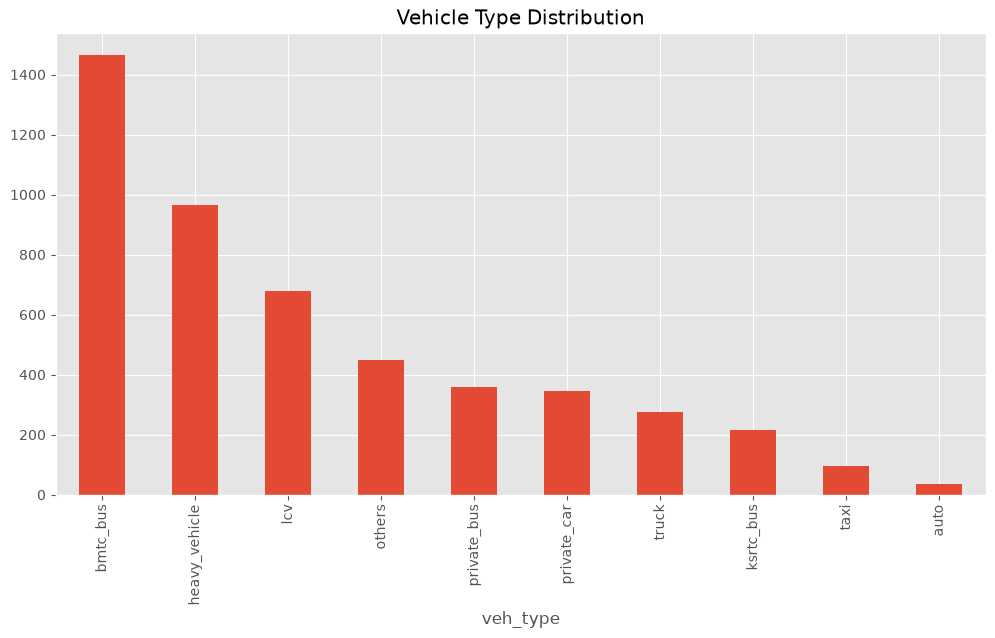

In [77]:
# =====================================================
# VEHICLE TYPE
# =====================================================

plt.figure(figsize=(12,6))

df["veh_type"] \
.value_counts() \
.head(10) \
.plot(kind="bar")

plt.title(
    "Vehicle Type Distribution"
)

plt.show()

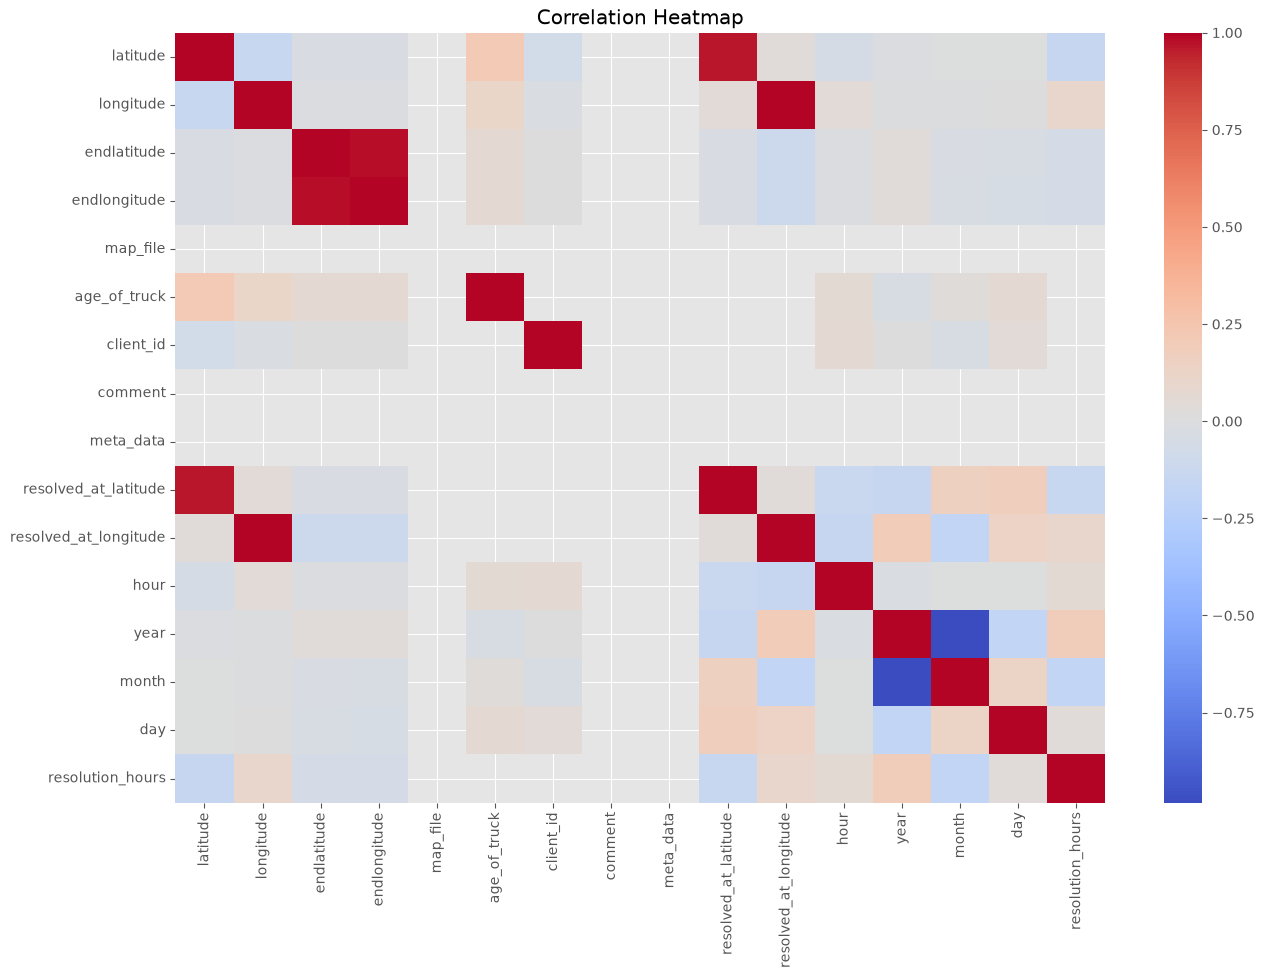

In [78]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

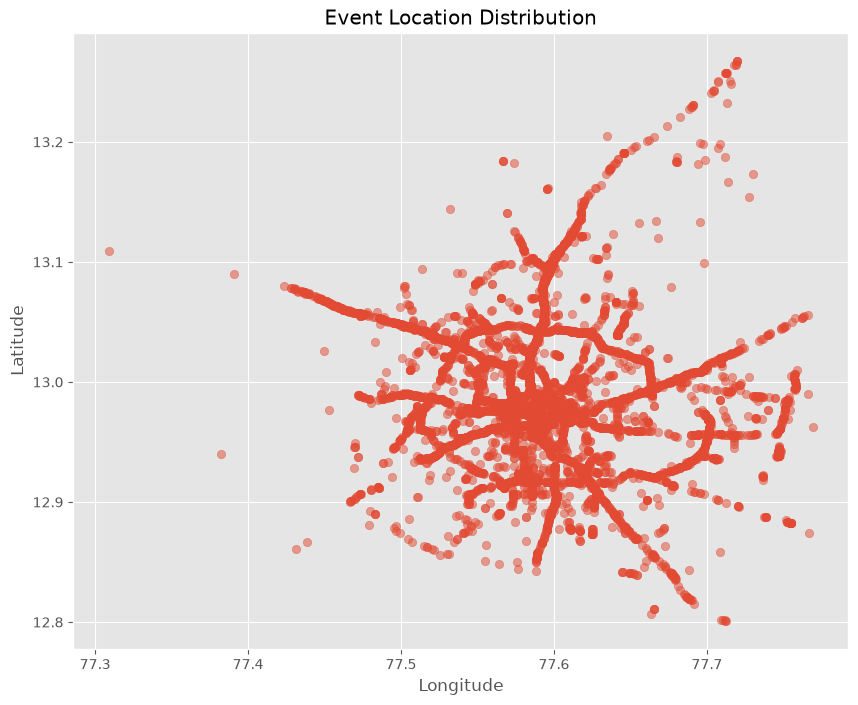

In [79]:
# =====================================================
# GEO VISUALIZATION
# =====================================================

plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Event Location Distribution"
)

plt.show()

In [80]:
# =====================================================
# PLOTLY MAP
# =====================================================

fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="event_cause",
    zoom=10,
    height=600
)

fig.update_layout(
    mapbox_style="open-street-map"
)

fig.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_21108\2141072143.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

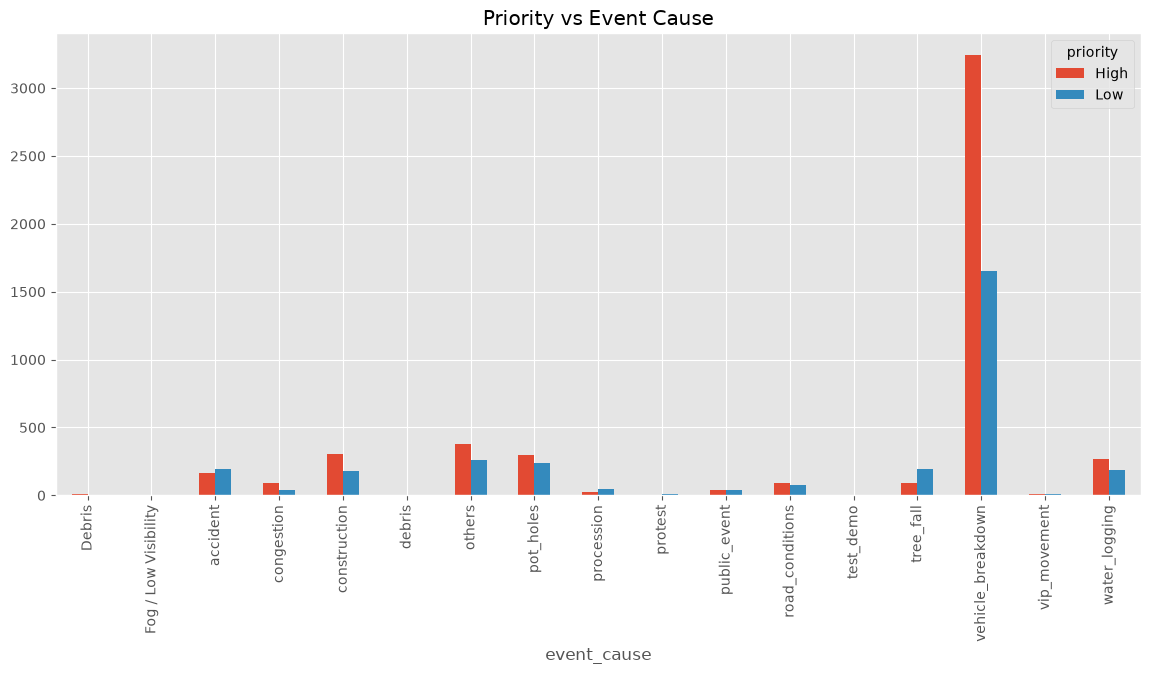

In [ ]:
# =====================================================
# PRIORITY VS EVENT CAUSE
# =====================================================

priority_cause = pd.crosstab(
    df["event_cause"],
    df["priority"]
)

priority_cause.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title(
    "Priority vs Event Cause"
)

plt.show()

In [81]:
# Corrected insights (fixed 'hours' -> 'hour' and made mode retrieval robust)
print("\nEDA INSIGHTS")
print("="*50)

def safe_mode(col):
    if col in df.columns:
        m = df[col].mode()
        return m.iat[0] if not m.empty else None
    return None

print("Most Common Event Cause:", safe_mode("event_cause"))
print("Most Affected Zone:", safe_mode("zone"))
print("Peak Hour:", safe_mode("hour"))
print("Most Common Vehicle:", safe_mode("veh_type"))
print("Most Common Priority:", safe_mode("priority"))

print("="*50)


EDA INSIGHTS
Most Common Event Cause: vehicle_breakdown
Most Affected Zone: Central Zone 2
Peak Hour: 21.0
Most Common Vehicle: bmtc_bus
Most Common Priority: High


In [82]:
# =====================================================
# INSIGHTS
# =====================================================

print("\nEDA INSIGHTS")
print("="*50)

print(
    "Most Common Event Cause:",
    df["event_cause"].mode()[0]
)

print(
    "Most Affected Zone:",
    df["zone"].mode()[0]
)

print(
    "Peak Hour:",
    df["hour"].mode()[0]
)

print(
    "Most Common Vehicle:",
    df["veh_type"].mode()[0]
)

print(
    "Most Common Priority:",
    df["priority"].mode()[0]
)

print("="*50)


EDA INSIGHTS
Most Common Event Cause: vehicle_breakdown
Most Affected Zone: Central Zone 2
Peak Hour: 21.0
Most Common Vehicle: bmtc_bus
Most Common Priority: High


In [84]:
# =====================================================
# FINAL EDA SUMMARY AND INSIGHTS
# =====================================================

print("\nFINAL EDA INSIGHTS")
print("="*50)

print(f"Total Events: {len(df)}")
print(f"Most Common Event Cause: {summary['Most Common Event']}")
print(f"Peak Hour: {int(summary['Peak Hour'])}")
print(f"Top Zone: {summary['Top Zone']}")
print(f"Total Junctions: {len(counts)}")
print(f"Most Affected Junction: {counts.index[1]}")  # Skip 'Missing' at index 0
print(f"Events Requiring Road Closure: {cross[True].sum()}")
print(f"Events Not Requiring Road Closure: {cross[False].sum()}")

print("="*50)


FINAL EDA INSIGHTS
Total Events: 8173
Most Common Event Cause: vehicle_breakdown
Peak Hour: 21
Top Zone: Central Zone 2
Total Junctions: 15
Most Affected Junction: MekhriCircle
Events Requiring Road Closure: 676
Events Not Requiring Road Closure: 7497


In [87]:
summary = {
    "Total Events": len(df),

    "Most Common Cause":
        df["event_cause"].mode()[0],

    "Peak Hour":
        df["hour"].mode()[0],

    "Top Zone":
        df["zone"].mode()[0],

    "Top Corridor":
        df["corridor"].mode()[0],

    "Road Closures":
        df["requires_road_closure"].sum()
        if df["requires_road_closure"].dtype != "object"
        else df["requires_road_closure"].value_counts().idxmax()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

import os
os.makedirs("reports", exist_ok=True)

summary_df.to_csv(
    "reports/eda_summary.csv",
    index=False
)

print(summary_df)
print("\nEDA Summary Saved Successfully")

              Metric              Value
0       Total Events               8173
1  Most Common Cause  vehicle_breakdown
2          Peak Hour               21.0
3           Top Zone     Central Zone 2
4       Top Corridor       Non-corridor
5      Road Closures                676

EDA Summary Saved Successfully
